In [1]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from  sklearn.model_selection import GridSearchCV

housing_original = pd .read_csv("housing.csv")

housing_original.info


ModuleNotFoundError: No module named 'numpy'

In [3]:
housing_original.iloc[:, :6].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population
0,-122.23,37.88,41.0,880.0,129.0,322.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0


In [4]:
housing_original.iloc[:, :5].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms
0,-122.23,37.88,41.0,880.0,129.0
1,-122.22,37.86,21.0,7099.0,1106.0
2,-122.24,37.85,52.0,1467.0,190.0
3,-122.25,37.85,52.0,1274.0,235.0
4,-122.25,37.85,52.0,1627.0,280.0


In [5]:
housing_original['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
housing = housing_original[housing_original['ocean_proximity'] != '<ISLAND']
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
hosuing = pd.get_dummies(housing, columns=['ocean_proximity'], dtype=int, prefix='dmy')

In [8]:
housing.iloc[[1, 200, 1000, 1850, 5000], 9:]

,ocean_proximity
1,NEAR BAY
200,NEAR BAY
1000,INLAND
1850,NEAR OCEAN
5000,<1H OCEAN


In [9]:
train_full, test = train_test_split(housing, test_size=0.2, random_state=40)
train, val = train_test_split(train_full, test_size=0.25, random_state=36)

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12384 entries, 5810 to 17977
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12384 non-null  float64
 1   latitude            12384 non-null  float64
 2   housing_median_age  12384 non-null  float64
 3   total_rooms         12384 non-null  float64
 4   total_bedrooms      12267 non-null  float64
 5   population          12384 non-null  float64
 6   households          12384 non-null  float64
 7   median_income       12384 non-null  float64
 8   median_house_value  12384 non-null  float64
 9   ocean_proximity     12384 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.0+ MB


In [11]:
train= train.dropna()
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12267 entries, 5810 to 17977
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12267 non-null  float64
 1   latitude            12267 non-null  float64
 2   housing_median_age  12267 non-null  float64
 3   total_rooms         12267 non-null  float64
 4   total_bedrooms      12267 non-null  float64
 5   population          12267 non-null  float64
 6   households          12267 non-null  float64
 7   median_income       12267 non-null  float64
 8   median_house_value  12267 non-null  float64
 9   ocean_proximity     12267 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.0+ MB


In [12]:
val = val.dropna()
test = test .dropna()

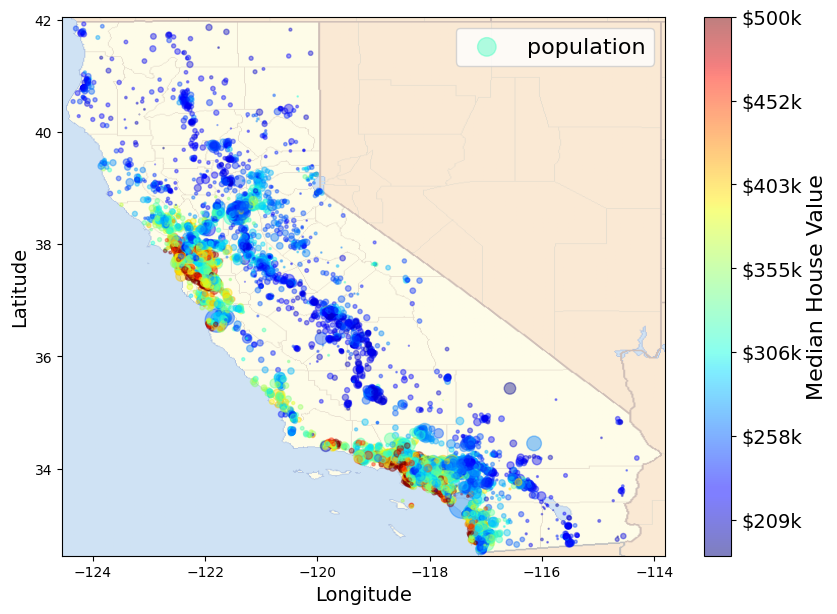

In [16]:
import matplotlib.image as mpimg
california_img= mpimg.imread ("california.png")
ax = train.plot(kind='scatter', x='longitude', y='latitude', figsize=(10,7),
                s=train['population']/100, label='population',
                c='median_house_value', cmap=plt.get_cmap('jet'),
                colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5, cmap=plt.get_cmap('jet'))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = train['median_house_value']
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values /prices.max())
cbar.ax.set_yticklabels(["$%dk" % (round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)
plt.legend(fontsize=16)